# Neural signal and model features: full II/R²/Σ⁻¹ pipeline

This notebook uses the loading and alignment choices of
`full_asymmetry_pipeline.ipynb`, then runs the same shared analysis as the
synthetic notebooks. Arrays are transposed once after loading so the shared
module consistently receives `(samples, features)`.

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from sklearn.decomposition import PCA
from torchvision.datasets import ImageFolder

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in [cwd, *cwd.parents] if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    project_config = yaml.safe_load(f)
paths = project_config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from II_analyses.asymmetry_pipeline import (
    run_asymmetry_pipeline,
    summarize_asymmetry_pipeline,
)
from project_specific_utils.dataloader import (
    load_img_natraster,
    map_image_order_from_ann_to_monkey,
)

plt.rcParams.update(
    {"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False}
)

In [2]:
@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    folder_name: str = "talia_20each_tizi"
    new_fs: int = 100
    neural_timepoint_idx: int = 17
    model_name: str = "vit_l_16"
    img_size: int = 384
    layer_name: str = "blocks.1.mlp.fc2"
    pooling: str = "mean"
    pca_components: int | None = 100
    neural_RDM_metric: str = "cosine_cnt"
    model_RDM_metric: str = "cosine_cnt"
    k: int = 10
    singular_value_rtol: float | None = None
# EOC


cfg = Cfg()
cfg

Cfg(monkey_name='three0', date='250313', brain_area='AIT', folder_name='talia_20each_tizi', new_fs=100, neural_timepoint_idx=17, model_name='vit_l_16', img_size=384, layer_name='blocks.1.mlp.fc2', pooling='mean', pca_components=100, neural_RDM_metric='cosine_cnt', model_RDM_metric='cosine_cnt', k=10, singular_value_rtol=None)

## Load and align the representations

The raster begins as `(neurons, timepoints, images)`. Model features begin as
`(features, images)` and are reordered to the monkey presentation order.

In [3]:
raster = load_img_natraster(
    paths,
    cfg.monkey_name,
    cfg.date,
    new_fs=cfg.new_fs,
    brain_area=cfg.brain_area,
)

dataset_path = Path(paths["livingstone_lab"]) / "Stimuli" / cfg.folder_name
dataset = ImageFolder(
    root=dataset_path,
    is_valid_file=lambda path: not path.endswith("Thumbs.db"),
    allow_empty=True,
)
idx_order = map_image_order_from_ann_to_monkey(
    paths, cfg.monkey_name, cfg.date, dataset
)

features_path = (
    Path(paths["data_path"])
    / "models"
    / (
        f"{cfg.folder_name}_{cfg.model_name}_{cfg.img_size}_{cfg.layer_name}"
        f"_features_{cfg.pooling}pool.npz"
    )
)
model_features = np.load(features_path)["arr_0"][:, idx_order]

if cfg.pca_components is not None:
    max_components = min(model_features.shape)
    if not 1 <= cfg.pca_components <= max_components:
        raise ValueError(
            f"pca_components must be between 1 and {max_components}."
        )
    # end if pca_components is invalid
    model_features = PCA(n_components=cfg.pca_components).fit_transform(
        model_features.T
    ).T
# end if cfg.pca_components is not None

raster_array = raster.get_array()
if raster_array.ndim != 3:
    raise ValueError(
        "Expected neural data with shape (neurons, timepoints, images), "
        f"received {raster_array.shape}."
    )
# end if raster_array.ndim != 3
if not -raster_array.shape[1] <= cfg.neural_timepoint_idx < raster_array.shape[1]:
    raise IndexError("neural_timepoint_idx is outside the recorded time range.")
# end if neural_timepoint_idx is invalid

timepoint_idx = cfg.neural_timepoint_idx % raster_array.shape[1]
neural_features = raster_array[:, timepoint_idx, :]
if neural_features.shape[1] != model_features.shape[1]:
    raise ValueError(
        "Neural and model spaces contain different image counts: "
        f"{neural_features.shape[1]} and {model_features.shape[1]}."
    )
# end if image counts differ

# The shared pipeline uses samples in rows.
neural_samples = neural_features.T
model_samples = model_features.T
time_from_raster_start_s = timepoint_idx / raster.get_fs()

print(f"Selected timepoint: {timepoint_idx} ({time_from_raster_start_s:.3f} s from raster start)")
print(f"Neural samples x neurons: {neural_samples.shape}")
print(f"Model samples x PCA features: {model_samples.shape}")
print(f"Model features loaded from: {features_path}")

Selected timepoint: 17 (0.170 s from raster start)
Neural samples x neurons: (776, 25)
Model samples x PCA features: (776, 100)
Model features loaded from: /Users/tizianocausin/metrics_II_local/models/talia_20each_tizi_vit_l_16_384_blocks.1.mlp.fc2_features_meanpool.npz


## Original II/R², reciprocal Σ⁻¹ transforms, and recomputed metrics

The two transformations are fitted independently: the neural representation is
transformed through the neural-to-model map, and the model representation
through the model-to-neural map. Numerical null singular directions remain zero.

In [4]:
pipeline = run_asymmetry_pipeline(
    neural_samples,
    model_samples,
    source_metric=cfg.neural_RDM_metric,
    target_metric=cfg.model_RDM_metric,
    k=cfg.k,
    relative_tolerance=cfg.singular_value_rtol,
)
summary = summarize_asymmetry_pipeline(pipeline, "neural", "model")
display(summary.style.format({"pooled R2": "{:.6f}", "II": "{:.6f}"}))

print(
    "neural -> model: "
    f"rank={pipeline['source_svd']['rank']}, "
    f"weight singular values={np.round(pipeline['source_svd']['singular_values'][:10], 6)}"
)
print(
    "model -> neural: "
    f"rank={pipeline['target_svd']['rank']}, "
    f"weight singular values={np.round(pipeline['target_svd']['singular_values'][:10], 6)}"
)
print(
    "Transformed samples: "
    f"neural_tilde={pipeline['transformed_source'].shape}, "
    f"model_tilde={pipeline['transformed_target'].shape}"
)

,stage,direction,R2 per output,pooled R2,II
0,original,neural -> model,"[0.110922, 0.167464, 0.039957, 0.057265, 0.052222, 0.02945, 0.042783, 0.022697, 0.075191, 0.053229, 0.072138, 0.05262, 0.043914, 0.041131, 0.09491, 0.053328, 0.046825, 0.033998, 0.047799, 0.03036, 0.034275, 0.041461, 0.051087, 0.048608, 0.048895, 0.037092, 0.042578, 0.050224, 0.024134, 0.058761, 0.055399, 0.031463, 0.042555, 0.058862, 0.0233, 0.027576, 0.027628, 0.050222, 0.044506, 0.041103, 0.030035, 0.032313, 0.042385, 0.037564, 0.038446, 0.049999, 0.04403, 0.028637, 0.025292, 0.03745, 0.037909, 0.044859, 0.025846, 0.041929, 0.028549, 0.047124, 0.048578, 0.039359, 0.0254, 0.026073, 0.027142, 0.026988, 0.025509, 0.034327, 0.026891, 0.02435, 0.036, 0.015703, 0.038056, 0.027722, 0.033304, 0.035393, 0.0252, 0.033265, 0.042845, 0.050463, 0.033981, 0.019739, 0.037458, 0.028556, 0.02068, 0.025123, 0.032871, 0.037539, 0.0288, 0.023436, 0.043673, 0.027243, 0.04421, 0.033175, 0.051815, 0.028201, 0.019293, 0.028203, 0.014559, 0.041667, 0.047088, 0.036987, 0.023685, 0.017773]",0.091226,0.932924
1,original,model -> neural,"[0.264369, 0.299346, 0.230175, 0.302045, 0.209636, 0.222759, 0.228301, 0.191999, 0.265563, 0.14391, 0.258749, 0.16808, 0.235331, 0.363147, 0.147025, 0.189536, 0.190203, 0.227473, 0.185324, 0.163599, 0.181185, 0.189986, 0.132197, 0.179921, 0.13037]",0.216143,0.811038
2,Sigma^-1 normalized,neural -> model,"[0.232006, 0.253714, 0.178004, 0.23857, 0.196354, 0.179306, 0.235402, 0.211854, 0.244606, 0.171216, 0.280039, 0.190128, 0.118657, 0.308871, 0.170584, 0.211634, 0.188784, 0.128791, 0.170022, 0.170839, 0.198217, 0.179319, 0.156765, 0.117906, 0.140372]",0.198004,0.754797
3,Sigma^-1 normalized,model -> neural,"[0.27822, 0.456638, 0.201057, 0.210614, 0.244115, 0.152299, 0.261558, 0.158875, 0.275114, 0.206983, 0.251208, 0.23265, 0.187107, 0.151478, 0.287785, 0.142293, 0.186339, 0.138149, 0.176232, 0.141056, 0.116205, 0.14549, 0.144521, 0.153043, 0.203393, 0.178936, 0.129893, 0.138125, 0.22662, 0.131885, 0.234301, 0.142468, 0.140965, 0.167141, 0.213418, 0.149315, 0.158357, 0.242501, 0.123832, 0.201421, 0.121369, 0.167232, 0.20488, 0.197648, 0.110786, 0.171448, 0.147209, 0.164086, 0.11649, 0.150079, 0.138776, 0.174768, 0.148148, 0.133864, 0.148925, 0.141242, 0.130301, 0.144004, 0.108269, 0.120977, 0.141497, 0.124826, 0.153173, 0.124195, 0.100564, 0.129107, 0.15409, 0.153678, 0.239411, 0.108935, 0.141851, 0.152039, 0.118082, 0.11274, 0.210383, 0.126966, 0.122155, 0.239362, 0.149595, 0.107585, 0.130293, 0.164752, 0.130344, 0.144938, 0.116518, 0.160348, 0.160972, 0.119912, 0.154714, 0.116891, 0.151027, 0.108689, 0.141371, 0.149245, 0.122256, 0.11677, 0.112342, 0.135479, 0.161044, 0.143914]",0.216143,0.728690


neural -> model: rank=25, weight singular values=[1.095888 0.37725  0.265111 0.231716 0.21373  0.192529 0.162973 0.150253
 0.138218 0.126031]
model -> neural: rank=25, weight singular values=[8.933628 6.446741 5.236475 4.808888 4.698276 4.110393 3.940821 3.783389
 3.608395 3.378538]
Transformed samples: neural_tilde=(776, 100), model_tilde=(776, 25)


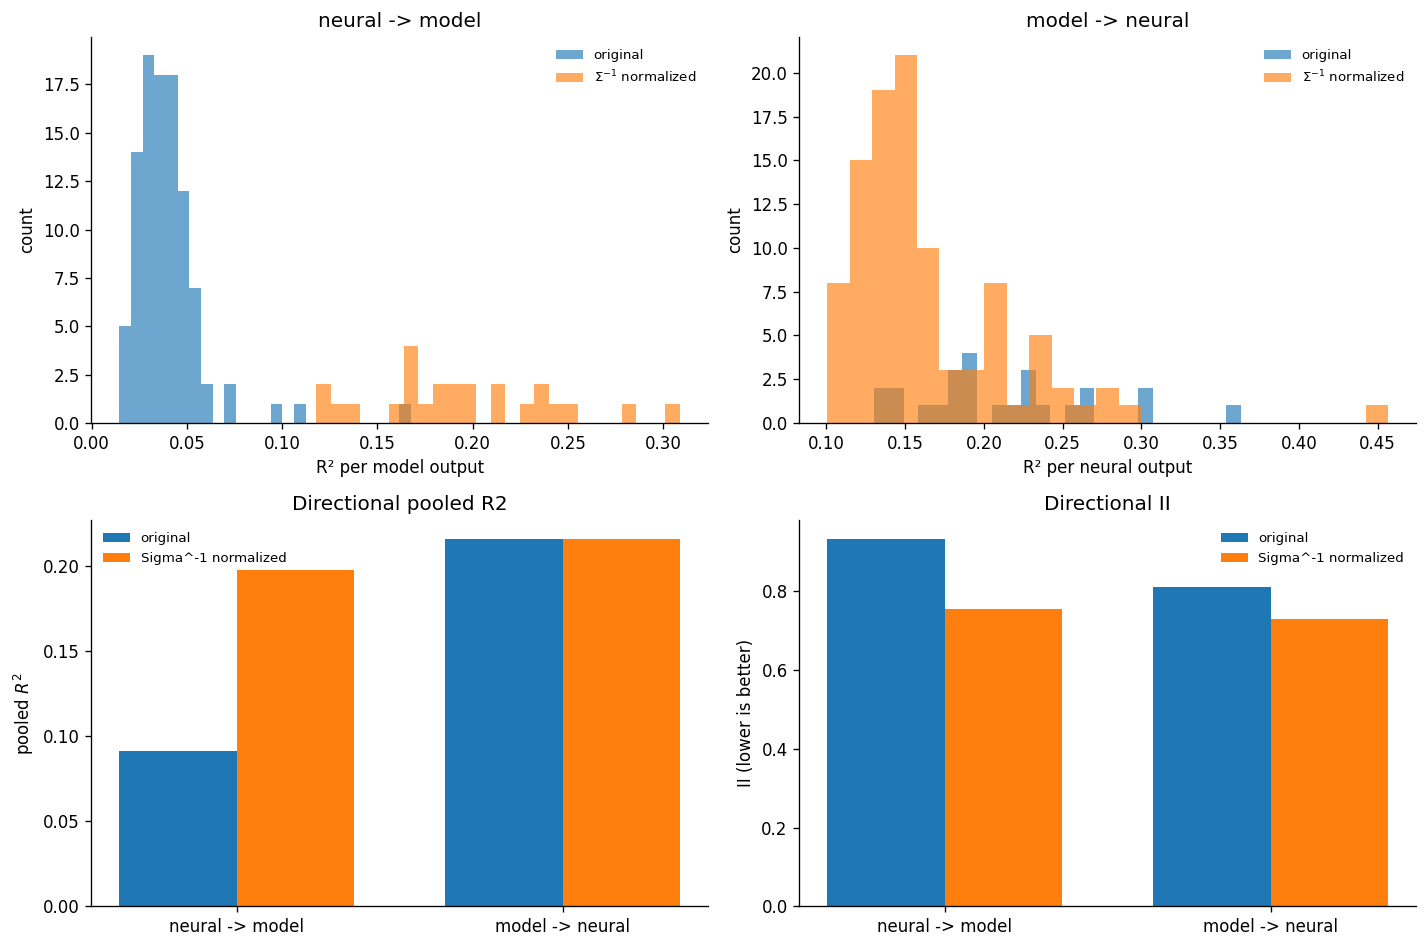

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
original_fit = pipeline["original_fit"]
transformed_fit = pipeline["transformed_fit"]

axes[0, 0].hist(
    original_fit["r2_source_to_target"], bins=25, alpha=0.65, label="original"
)
axes[0, 0].hist(
    transformed_fit["r2_source_to_target"], bins=25, alpha=0.65,
    label=r"$\Sigma^{-1}$ normalized",
)
axes[0, 0].set(title="neural -> model", xlabel="R² per model output", ylabel="count")

axes[0, 1].hist(
    original_fit["r2_target_to_source"], bins=25, alpha=0.65, label="original"
)
axes[0, 1].hist(
    transformed_fit["r2_target_to_source"], bins=25, alpha=0.65,
    label=r"$\Sigma^{-1}$ normalized",
)
axes[0, 1].set(title="model -> neural", xlabel="R² per neural output", ylabel="count")

for ax, metric, ylabel in (
    (axes[1, 0], "pooled R2", r"pooled $R^2$"),
    (axes[1, 1], "II", "II (lower is better)"),
):
    x_positions = np.arange(2)
    width = 0.36
    for offset, (stage, stage_rows) in zip(
        (-width / 2, width / 2), summary.groupby("stage", sort=False)
    ):
        ax.bar(x_positions + offset, stage_rows[metric], width, label=stage)
    # end for offset, (stage, stage_rows)
    ax.set_xticks(x_positions, ["neural -> model", "model -> neural"])
    ax.set(ylabel=ylabel, title=f"Directional {metric}")
# end for ax, metric, ylabel

for ax in axes.flat:
    ax.legend(frameon=False, fontsize=8)
# end for ax in axes.flat
fig.tight_layout()
plt.show()

## Interpretation caveat

These are descriptive in-sample OLS values, matching the Gaussian source
notebook. High-dimensional representations can interpolate targets, so these
pooled R² values should not be read as held-out generalization performance.
II is computed directly from each representation before and after the fitted
transforms; it is not computed from regression predictions.